In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Tuple

from deltafq.strategy.base import BaseStrategy

In [2]:
# 1. 读取基金数据，并重命名列名，以适应dfq回测等
data = pd.read_csv("160119.csv",index_col='净值日期')
data.index = pd.to_datetime(data.index)
data = data.rename(columns={'单位净值': 'close'})
data.index.name = 'date'

# 定义回测日期
start_date = '2021-01-01'
end_date = '2025-12-25'
data = data[start_date:end_date]

data

,close,累计净值,日增长率,申购状态,赎回状态,分红送配
date,,,,,,
2021-01-04,1.6907,1.7907,1.74%,开放申购,开放赎回,NaN
2021-01-05,1.7046,1.8046,0.82%,开放申购,开放赎回,NaN
2021-01-06,1.7018,1.8018,-0.16%,开放申购,开放赎回,NaN
2021-01-07,1.7042,1.8042,0.14%,开放申购,开放赎回,NaN
2021-01-08,1.7096,1.8096,0.32%,开放申购,开放赎回,NaN
...,...,...,...,...,...,...
2025-12-19,2.0168,2.1168,0.94%,开放申购,开放赎回,NaN
2025-12-22,2.0399,2.1399,1.15%,开放申购,开放赎回,NaN
2025-12-23,2.0401,2.1401,0.01%,开放申购,开放赎回,NaN


In [11]:
# 2. 定投策略：每周四定投，如周四非交易日，则选择最近交易日，以确保每周定投预算用完
class DCAStrategy(BaseStrategy):
    """每周四定投策略（自动选择最近交易日）"""
    
    def generate_signals(self, data: pd.DataFrame) -> pd.Series:
        signals = pd.Series(0, index=data.index, dtype=int)
        
        # 获取数据的时间范围
        start_date = data.index[0]
        end_date = data.index[-1]
        
        # 生成所有周四的日期
        thursdays = pd.date_range(start=start_date, end=end_date, freq='W-THU')
        
        # 对每个周四，找到最近的交易日
        for thursday in thursdays:
            # 使用 asof 找到最近的交易日（向前查找）
            nearest = data.index.asof(thursday)
            if nearest is not pd.NaT and nearest in data.index:
                # 如果找到的交易日还没有被标记，则标记
                if signals.loc[nearest] == 0:
                    signals.loc[nearest] = 1
            else:
                # 如果向前找不到，向后查找第一个交易日
                after = data.index[data.index > thursday]
                if len(after) > 0:
                    nearest = after[0]
                    if signals.loc[nearest] == 0:
                        signals.loc[nearest] = 1
        
        return signals

# 使用策略
strategy = DCAStrategy(name="DCAStrategy")
result = strategy.run(data)
signals = result["signals"]

print(f"策略名称: {result['strategy_name']}")
print(f"买入信号数: {(signals == 1).sum()}")
print(f"持有信号数: {(signals == 0).sum()}")

[20:29:15] DCAStrategy          >>> INFO     >>> Initializing strategy: DCAStrategy
[20:29:15] DCAStrategy          >>> INFO     >>> Running strategy: DCAStrategy
策略名称: DCAStrategy
买入信号数: 257
持有信号数: 954


In [12]:
signals

date
2021-01-04    0
2021-01-05    0
2021-01-06    0
2021-01-07    1
2021-01-08    0
             ..
2025-12-19    0
2025-12-22    0
2025-12-23    0
2025-12-24    0
2025-12-25    1
Length: 1211, dtype: int64

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_fund_signals(data: pd.DataFrame, signals: pd.Series, title: str = "定投策略信号图") -> None:
    """可视化基金价格和买入信号"""
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, (ax_price, ax_signal) = plt.subplots(
        2, 1, figsize=(12, 6), sharex=True, 
        gridspec_kw={"height_ratios": [4, 1]}
    )
    
    # 价格图
    ax_price.plot(data.index, data['close'], color="#2563eb", linewidth=1.2, label="净值")
    buy_mask = signals == 1
    ax_price.scatter(
        data.index[buy_mask],
        data['close'][buy_mask],
        marker="^",
        color="#ef4444",
        edgecolors="white",
        linewidths=0.6,
        s=140,
        label="买入",
        zorder=3
    )
    
    ax_price.set_title(title, fontsize=14)
    ax_price.set_ylabel("净值")
    ax_price.grid(True, alpha=0.2, color="#d1d5db")
    ax_price.legend(frameon=False, loc="upper left")
    
    # 信号图
    ax_signal.plot(signals.index, signals.values, color="#6b7280", linewidth=1.0, linestyle=":")
    ax_signal.set_ylabel("信号")
    ax_signal.set_xlabel("日期")
    ax_signal.set_yticks([0, 1])
    ax_signal.set_yticklabels(["持有", "买入"])
    ax_signal.grid(True, alpha=0.2, color="#d1d5db")
    
    # 日期格式
    for ax in (ax_price, ax_signal):
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

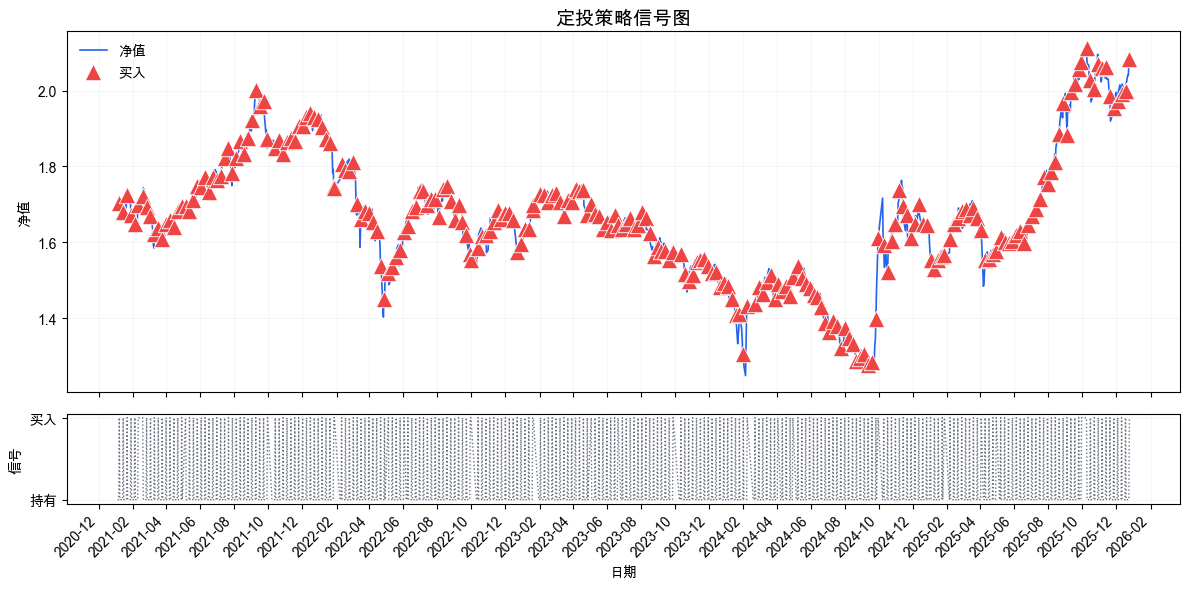

In [14]:
plot_fund_signals(data, signals)

In [15]:
# 4. 运行回测：重写回测逻辑，因为定投策略是逐步加仓概念，而非deltafq-backtest中的全仓进出
from datetime import datetime

def backtest_dca(data: pd.DataFrame, signals: pd.Series, 
                 investment_amount: float = 1000, 
                 commission: float = 0.001) -> Tuple[pd.DataFrame, dict]:
    """
    定投策略回测
    
    Args:
        data: 包含close列的数据
        signals: 买入信号序列（1=买入，0=持有）
        investment_amount: 每次定投金额
        commission: 手续费率
    
    Returns:
        values_df: 每日资产明细
        summary: 回测摘要
    """
    shares = 0
    total_invested = 0
    records = []
    
    for date, row in data.iterrows():
        price = row['close']
        signal = signals.loc[date] if date in signals.index else 0
        
        # 买入信号：定投固定金额
        if signal == 1:
            # 投入1000元，扣除手续费后用于买入
            net_amount = investment_amount * (1 - commission)  # 实际买入金额
            shares_bought = net_amount / price
            shares += shares_bought
            total_invested += investment_amount
        
        # 计算资产
        position_value = shares * price
        total_value = position_value
        
        records.append({
            'date': date,
            'price': price,
            'signal': signal,
            'shares': shares,
            'position_value': position_value,
            'total_value': total_value,
            'total_invested': total_invested
        })
    
    values_df = pd.DataFrame(records).set_index('date')
    
    # 计算摘要
    final_value = values_df['total_value'].iloc[-1]
    total_return = (final_value / total_invested - 1) * 100 if total_invested > 0 else 0
    buy_count = (signals == 1).sum()
    
    # 计算年化收益率
    start_date = values_df.index[0]
    end_date = values_df.index[-1]
    years = (end_date - start_date).days / 365.25
    annual_return = ((final_value / total_invested) ** (1 / years) - 1) * 100 if total_invested > 0 and years > 0 else 0
    
    summary = {
        '累计投入': f'{total_invested:,.2f}',
        '最终资产': f'{final_value:,.2f}',
        '累计收益': f'{final_value - total_invested:,.2f}',
        '累计收益率': f'{total_return:.2f}%',
        '年化收益率': f'{annual_return:.2f}%',
        '投资年限': f'{years:.2f}年',
        '定投次数': buy_count,
        '持有份额': f'{shares:,.4f}',
        '最终净值': f'{values_df["price"].iloc[-1]:.4f}',
        '起始日期': start_date.strftime('%Y-%m-%d'),
        '结束日期': end_date.strftime('%Y-%m-%d')
    }
    
    return values_df, summary

def print_summary(summary: dict, title: str = "回测摘要"):
    """格式化打印回测摘要"""
    print("=" * 50)
    print(f"  {title}")
    print("=" * 50)
    for key, value in summary.items():
        print(f"  {key:12s}: {value}")
    print("=" * 50)

In [16]:
# 运行回测
values_df, summary = backtest_dca(data, signals, investment_amount=500, commission=0)

# 格式化打印摘要
print_summary(summary)

# 查看最近10天资产
print("\n最近10天资产:")
print(values_df[['price', 'signal', 'shares', 'total_value', 'total_invested']].tail(10))

  回测摘要
  累计投入        : 128,500.00
  最终资产        : 161,963.13
  累计收益        : 33,463.13
  累计收益率       : 26.04%
  年化收益率       : 4.76%
  投资年限        : 4.97年
  定投次数        : 257
  持有份额        : 77,795.8265
  最终净值        : 2.0819
  起始日期        : 2021-01-04
  结束日期        : 2025-12-25

最近10天资产:
             price  signal        shares    total_value  total_invested
date                                                                   
2025-12-12  2.0172       0  77305.423493  155940.500270          127500
2025-12-15  2.0013       0  77305.423493  154711.344036          127500
2025-12-16  1.9708       0  77305.423493  152353.528620          127500
2025-12-17  2.0077       0  77305.423493  155206.098747          127500
2025-12-18  1.9981       1  77555.661219  154963.966681          128000
2025-12-19  2.0168       0  77555.661219  156414.257546          128000
2025-12-22  2.0399       0  77555.661219  158205.793320          128000
2025-12-23  2.0401       0  77555.661219  158221.304452        

In [17]:
# 5. 可视化回测结果：使用deltafq内置的 performance chart
from deltafq.charts import PerformanceChart

def plot_backtest_performance(values_df: pd.DataFrame, 
                              benchmark_close: pd.Series = None,
                              title: str = "定投策略回测表现",
                              use_plotly: bool = True):
    """使用PerformanceChart可视化回测结果"""
    performance_chart = PerformanceChart()
    performance_chart.plot_backtest_charts(
        values_df=values_df,
        benchmark_close=benchmark_close,
        title=title,
        use_plotly=use_plotly
    )

In [23]:
def plot_backtest_performance(values_df: pd.DataFrame, 
                              benchmark_close: pd.Series = None,
                              title: str = "定投策略回测表现",
                              use_plotly: bool = False):
    """使用PerformanceChart可视化回测结果"""
    # 确保 values_df 格式正确
    values_df = values_df.copy()
    
    # 从第一次有资产开始（避免初始为0导致的计算问题）
    first_valid_idx = values_df[values_df['total_value'] > 0].index
    if len(first_valid_idx) > 0:
        values_df = values_df.loc[first_valid_idx[0]:]
    
    # 清理无效值
    values_df['total_value'] = values_df['total_value'].replace([float('inf'), -float('inf')], 0)
    values_df['total_value'] = values_df['total_value'].fillna(0)
    values_df['price'] = values_df['price'].fillna(method='ffill').fillna(method='bfill')
    
    # 确保 total_value 至少有一个非零值
    if (values_df['total_value'] == 0).all():
        values_df.loc[values_df.index[0], 'total_value'] = 1.0
    
    # 对齐 benchmark_close 索引
    if benchmark_close is not None:
        benchmark_close = benchmark_close.reindex(values_df.index, method='ffill').fillna(method='bfill')
        # 清理 benchmark 的无效值
        benchmark_close = benchmark_close.replace([float('inf'), -float('inf')], 0)
        benchmark_close = benchmark_close.fillna(method='ffill').fillna(method='bfill')
    
    performance_chart = PerformanceChart()
    performance_chart.plot_backtest_charts(
        values_df=values_df,
        benchmark_close=benchmark_close,
        title=title,
        use_plotly=use_plotly
    )

[20:35:39] PerformanceChart     >>> INFO     >>> Initializing performance chart


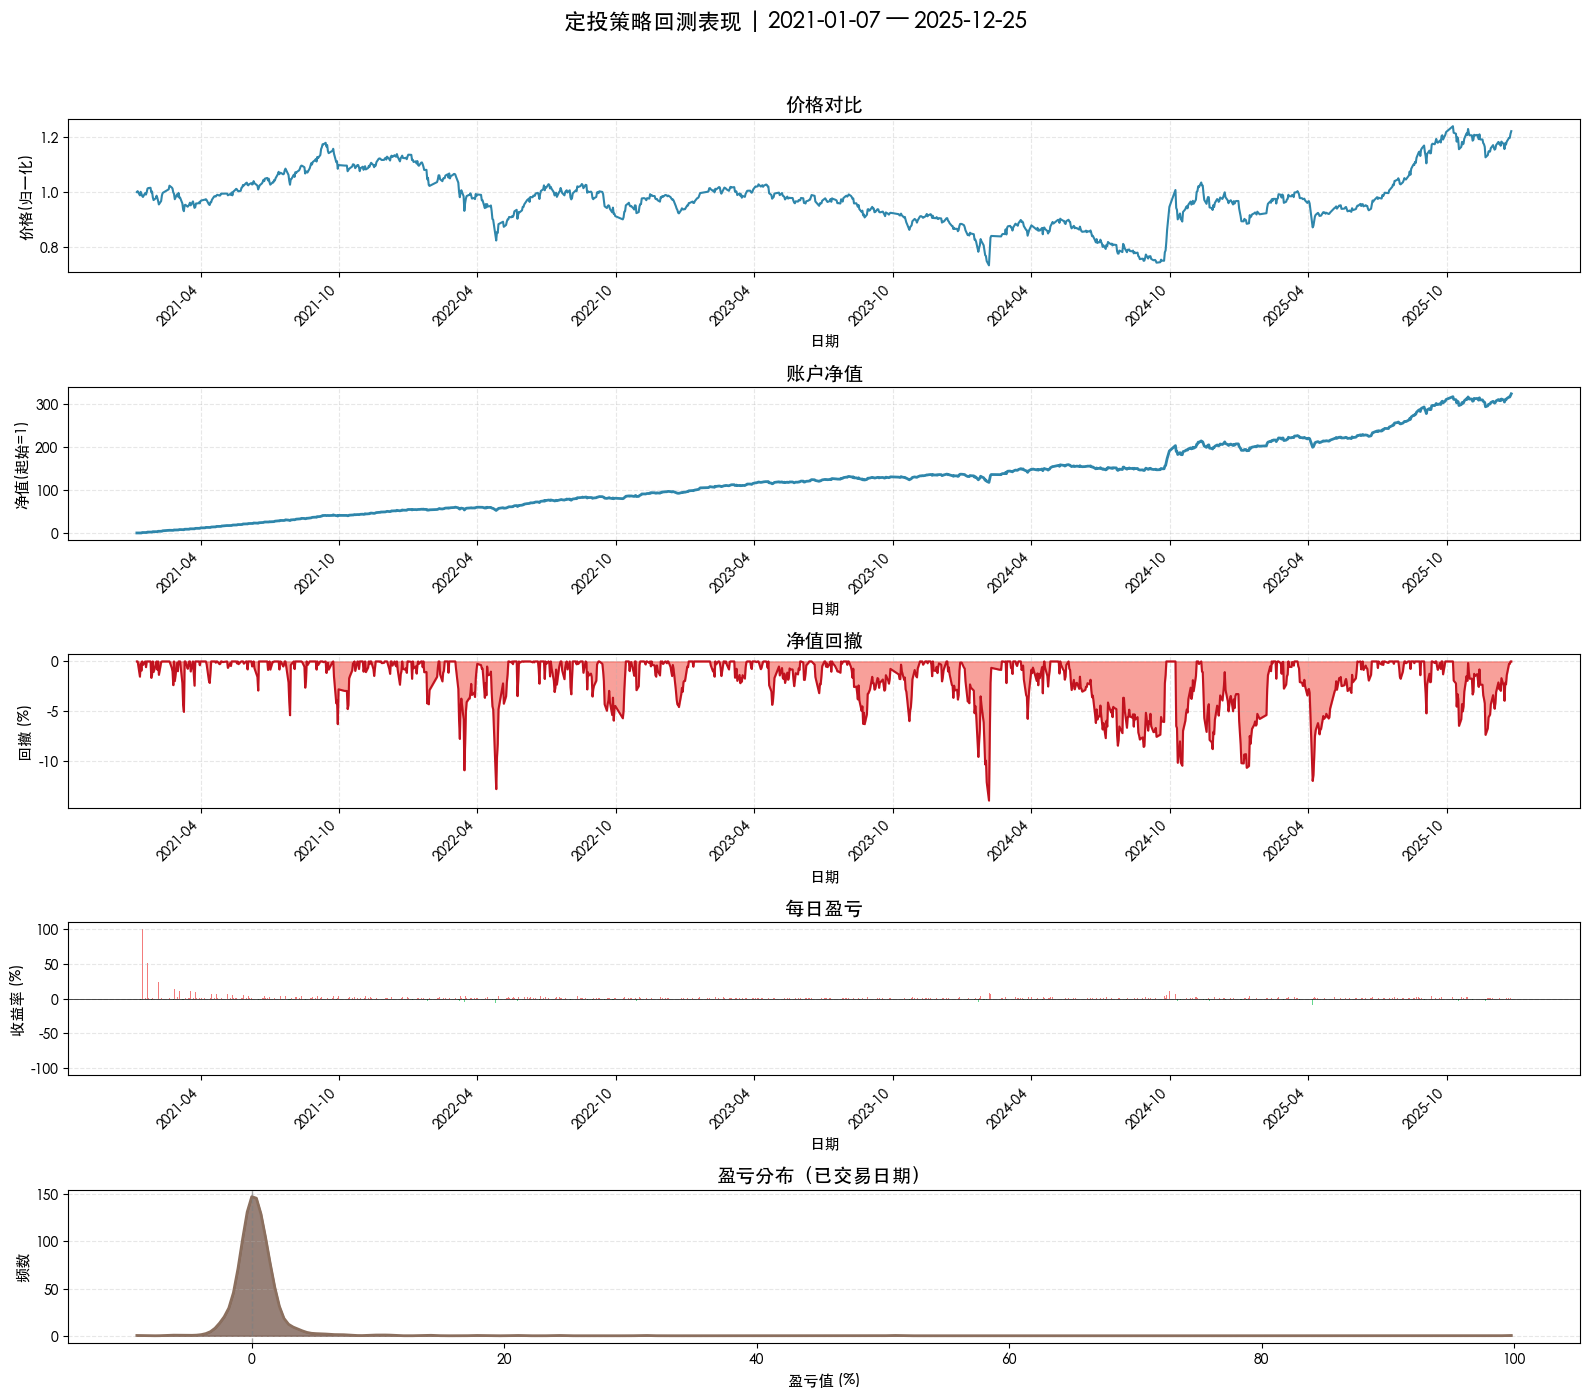

In [24]:
plot_backtest_performance(values_df=values_df)